In [63]:
import pandas as pd
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [64]:
df = pd.read_csv('bank-full.csv', sep=";")

In [65]:

print(df.head())


print(df.info())


print(df.describe())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

In [66]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [67]:
print(df.duplicated().value_counts())

False    45211
Name: count, dtype: int64


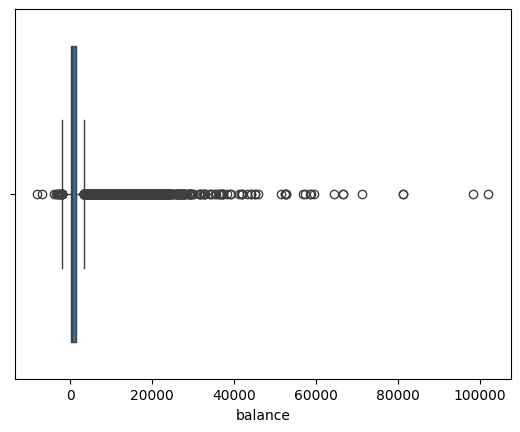

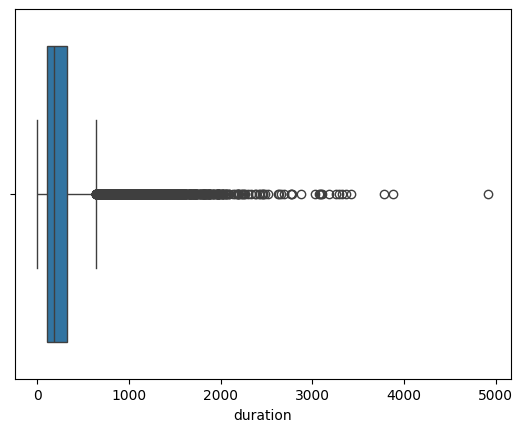

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de distribución para detectar posibles outliers en la columna balance
sns.boxplot(x=df['balance'])
plt.show()

# Gráfico de distribución para la duración de la llamada
sns.boxplot(x=df['duration'])
plt.show()


In [69]:
# Cargar el conjunto de datos
# Definir el diccionario de codificación
feature_label_dict = {
    'default': {'no': 0, 'yes': 1},
    'housing': {'no': 0, 'yes': 1},
    'loan': {'no': 0, 'yes': 1},
    'month': {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12},
    'y': {'no': 0, 'yes': 1},
    'contact': {'unknown': 0, 'cellular': 1, 'telephone': 2},
    'education': {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3},
    'poutcome': {'unknown': 0, 'other': 1, 'failure': 2, 'success': 3},
    'marital': {'divorced': 0, 'single': 1, 'married': 2},
    'job': {'unknown': 0, 'unemployed': 1, 'student': 2, 'management': 3, 'technician': 4, 'entrepreneur': 5, 'blue-collar': 6, 'retired': 7, 'admin.': 8, 'services': 9, 'self-employed': 10, 'housemaid': 11}
}

# Codificación de variables categóricas usando replace
for col in feature_label_dict.keys():
    df[col] = df[col].replace(feature_label_dict[col])

# Verificar si hay valores faltantes después de la codificación
print(df.isnull().sum())

# Agrupando edad en rangos
bins = [18, 30, 40, 50, 60, 70, 120]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['age_range'] = pd.cut(df['age'], bins=bins, labels=labels)
df['age'] = LabelEncoder().fit_transform(df['age_range'])
df = df.drop(['age_range'], axis=1)

# Mostrar los primeros registros para verificar la transformación
df.head()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


C:\Users\57301\AppData\Local\Temp\ipykernel_32880\3235250559.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(feature_label_dict[col])


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,3,3,2,3,0,2143,1,0,0,5,5,261,1,-1,0,0,0
1,2,4,1,2,0,29,1,0,0,5,5,151,1,-1,0,0,0
2,1,5,2,2,0,2,1,1,0,5,5,76,1,-1,0,0,0
3,2,6,2,0,0,1506,1,0,0,5,5,92,1,-1,0,0,0
4,1,0,1,0,0,1,0,0,0,5,5,198,1,-1,0,0,0


In [70]:
# Separar características y etiqueta
X = df.drop(['y'], axis=1)
y = df['y']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [71]:
# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [72]:
print(X.isnull().sum())


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


In [73]:
# Configurar el clasificador de red neuronal
model = MLPClassifier(hidden_layer_sizes=(15, 5), activation='relu', solver='adam', max_iter=1500, random_state=42)

# Entrenar el modelo
model.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(15, 5), max_iter=1500, random_state=42)

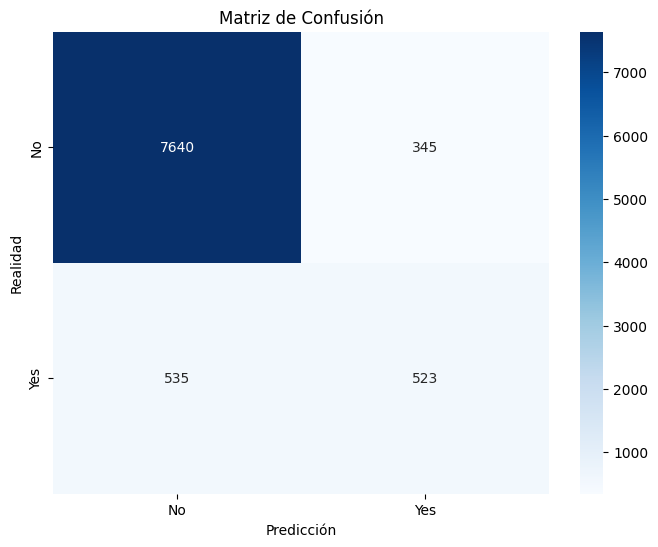

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7985
           1       0.60      0.49      0.54      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.73      0.74      9043
weighted avg       0.90      0.90      0.90      9043



In [74]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Evaluar el modelo
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Mostrar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')

plt.ylabel('Realidad')
plt.show()

# Imprimir el reporte de clasificación
print(report)
